# **Introduction**
Les fractures osseuses correspondent à une rupture ou une fissure d’un os, généralement causée par un traumatisme (chute, accident) ou par une fragilité osseuse, comme dans le cas de l’ostéoporose. Elles peuvent varier en gravité, allant d’une simple fissure à une fracture complexe avec fragmentation de l’os.

Le diagnostic des fractures repose principalement sur l’imagerie médicale, notamment la radiographie (rayons X), permettant de localiser et de caractériser précisément la lésion.

Aujourd’hui, les avancées en intelligence artificielle, en particulier en deep learning, offrent de nouvelles perspectives pour automatiser la détection et la classification des fractures, améliorant ainsi la précision du diagnostic et la rapidité de la prise en charge.


# **Objectif**
L’objectif de ce travail est d’analyser la classification des fractures osseuses à l’aide de deux modèles de deep learning, à savoir les réseaux de neurones convolutifs (CNN) et le modèle VGG16.

Par la suite, différentes techniques d’optimisation sont évaluées, notamment le prétraitement des données, l’augmentation et les transformations d’images, ainsi que le réglage des paramètres du modèle, afin d’améliorer les performances du système en termes de précision et de fiabilité.

Enfin, une analyse des résultats obtenus est réalisée pour comparer l’efficacité des approches proposées.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install split-folders
!pip install Augmentor



In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['meningioma-care-scan.jpg', 'Classroom', 'Norman S. Nise - Control Systems Engineering-Wiley (2015)-1.gdoc', 'Samira oulhi.pdf', 'dm.pdf', 'DM TTS.pdf', 'Formation python.jpg', 'DM gramma p2 .pdf', 'convention de stage pratique 19-12-21 10.16.36.pdf', 'OULHI SAMIA.PDF', 'Table_de_verite_du_CI_74LS139.gif', 'Table_de_verite_du_CI_74153.gif', 'TP FONCTIONS COMBINATOIRES SUR CI (TP N°3).pdf', 'tp2 SALC.pdf', 'NoteING1.xlsx', 'TD1corexo7a11..pdf', 'PVnotes_SE1_TTS1.pdf', 'convention de stage.pdf', 'pv global se 1 ing.pdf', 'SE-1.rar', 'pv semestriel.pdf', 'Colab Notebooks', 'GEII-PV Classement22-23.pdf', 'mini-project article.pdf', 'new_min.pdf', 'D1.PNG', 'D11.pdf', 'Dataset_test.csv', 'Dataset_train.csv', 'Dataset_test2.csv', 'Dataset_train2.csv', 'Data.rar', 'datasetfinal.csv', 'dataset2.csv', 'dataset.csv', 'dataset22.csv', 'datasetmod.csv', 'datasetV13.csv', 'datasetV1.csv', 'datasetV2.csv', 'datasetV22.csv', 'datasetV12.csv', 'datasetV23.csv', 'dataset3.csv', 'datasetV3.csv', 'ABC T

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models,optimizers
from tensorflow.keras.layers import BatchNormalization
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import splitfolders
import pickle
from tensorflow.keras.layers import Activation
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import model_from_json
import os
from PIL import Image, ImageEnhance




# **1 Présentation des classes**
---
##  Spiral Fracture
Cette fracture est causée par une force de torsion appliquée sur l’os.  
La ligne de fracture suit une trajectoire en spirale autour de l’os.  
Elle est souvent observée dans les blessures sportives ou les accidents impliquant une rotation brutale du membre.

---

## Longitudinal fracture
La fracture suit l’axe longitudinal de l’os.  
Elle est relativement rare car les os résistent mieux aux forces appliquées dans le sens de leur longueur.

---

##  Greenstick fracture
Ce type de fracture est incomplet : l’os se plie et se fissure sans se casser totalement.  
Elle est fréquente chez les enfants car leurs os sont plus flexibles.

---

##  Fracture Dislocation
Il s’agit d’une combinaison entre une fracture osseuse et une luxation articulaire.  
Elle provoque une instabilité importante de l’articulation concernée.

---

##  Hairline fracture
C’est une micro-fracture fine, souvent difficile à détecter sur les radiographies.  
Elle correspond à une fissure légère de l’os sans déplacement.

---

##  Impacted fracture
Les fragments de l’os fracturé sont enfoncés les uns dans les autres.  
Ce type de fracture est souvent causé par une chute ou un choc axial.

---

##  Oblique fracture
La ligne de fracture est diagonale par rapport à l’axe de l’os.  
Elle est généralement causée par une force appliquée en biais.

---

##  Pathological fracture
Cette fracture survient sur un os déjà fragilisé par une maladie (ostéoporose, tumeur, infection).  
Elle peut se produire avec un traumatisme très léger.

---

## Avulsion fracture
Un fragment d’os est arraché par une traction excessive d’un tendon ou ligament.  
Elle est fréquente chez les sportifs lors de mouvements brusques.

---

##  Comminuted fracture
L’os est fragmenté en plusieurs morceaux.  
Elle résulte généralement d’un traumatisme violent comme un accident de la route.

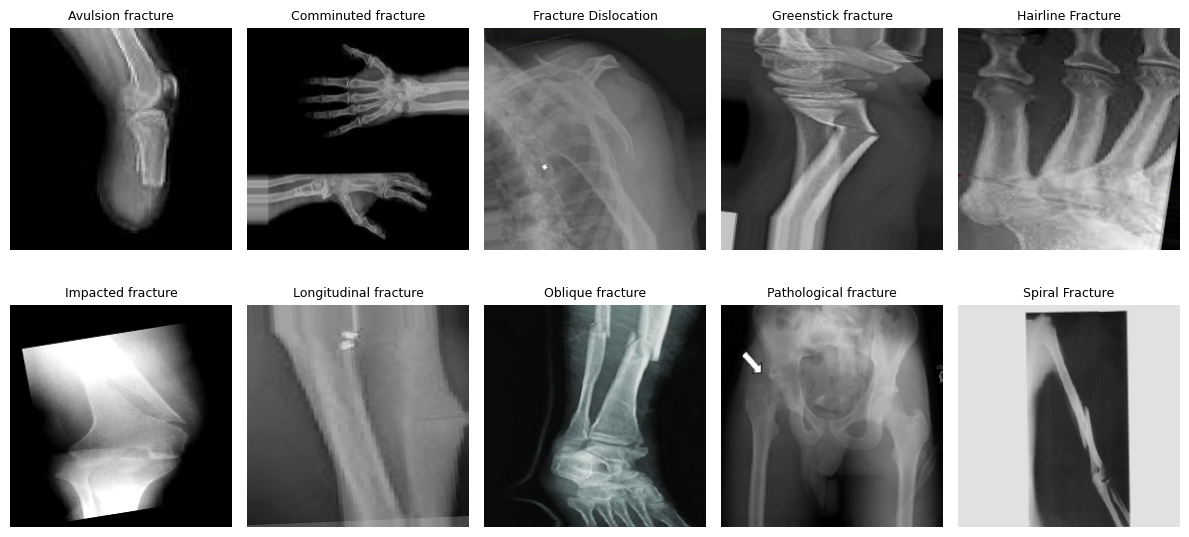

In [ ]:
classes = list(data_train1.class_indices.keys())
nb_classes = len(classes)
images_par_classe = 1

images_classe = {i: [] for i in range(nb_classes)}

while True:
    images, labels = next(data_train1)

    for k in range(len(images)):
        classe = np.argmax(labels[k])

        if len(images_classe[classe]) < images_par_classe:
            images_classe[classe].append(images[k])

    if all(len(images_classe[i]) == images_par_classe for i in range(nb_classes)):
        break

plt.figure(figsize=(12,6))

for i in range(nb_classes):
    plt.subplot(2, 5, i+1)
    plt.imshow(images_classe[i][0])
    plt.title(classes[i], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **2 Description de base de données**


Dans ce projet, nous utilisons une base de données composée de 1129 images radiographiques, réparties en 10 types de fractures osseuses.

Cependant, cette base présente quelques difficultés. Tout d’abord, il existe un déséquilibre entre les classes. Cela s’explique par le fait que certains types de fractures sont plus rares en réalité. Par exemple, les fractures longitudinales, spiralées ou impacted apparaissent dans des situations spécifiques (torsion ou compression), donc il y a moins d’images disponibles pour ces classes.

Ensuite, la qualité des images n’est pas toujours bonne. Certaines radiographies ont une faible résolution, ce qui rend difficile de voir clairement les débuts de fracture. Parfois, même pour un humain, il est difficile de distinguer s’il y a une fracture ou non.

Enfin, les images ne sont pas homogènes : certaines sont en couleur (RGB), d’autres en niveau de gris, et elles n’ont pas toutes la même taille ni les mêmes conditions (luminosité, contraste, angle). Cela complique le travail du modèle.

Pour résoudre ces problèmes, il est nécessaire de faire un prétraitement des images, comme le redimensionnement et la normalisation  afin d’améliorer les performances du modèle.

In [ ]:
import os

def count_images_per_class(folder):
    for cls in os.listdir(folder):
        class_path = os.path.join(folder, cls)

        print("Lecture :", class_path)

        if os.path.isdir(class_path):
            try:
                files = os.listdir(class_path)
                count = sum(f.lower().endswith(".jpg") for f in files)
                print(f"Classe: {cls} -> {count} images")
            except Exception as e:
                print("Erreur dans :", class_path)
                print(e)

count_images_per_class(rep)

Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Greenstick fracture
Classe: Greenstick fracture -> 122 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Comminuted fracture
Classe: Comminuted fracture -> 148 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Hairline Fracture
Classe: Hairline Fracture -> 111 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Oblique fracture
Classe: Oblique fracture -> 85 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Spiral Fracture
Classe: Spiral Fracture -> 86 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Impacted fracture
Classe: Impacted fracture -> 84 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Longitudinal fracture
Classe: Longitudinal fracture -> 80 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Fracture Dislocation
Classe: Fracture Dislocation -> 156 images
Lecture : /content/drive/MyDrive/G2_SIA2_fracture_os/Pathological fracture
Classe: Pathological frac

# **3 Prétraitement des données**

## Chargement des données

Les images sont organisées en trois dossiers : **train**, **validation** et **test** (après l’utilisation de la méthode *split folder*). Elles sont chargées automatiquement à l’aide de la fonction `flow_from_directory`, qui permet d’associer chaque image à sa classe correspondante.

Après chargement, on obtient :
- 899 images pour l’entraînement  
- 109 images pour la validation  
- 121 images pour le test  
toutes réparties en 10 classes.

Cette séparation des données est essentielle, car elle permet d’entraîner le modèle sur un ensemble (train), d’ajuster ses paramètres (validation), puis d’évaluer ses performances sur des données jamais vues (test). Cela garantit une meilleure **capacité de généralisation**, c’est-à-dire que le modèle apprend à reconnaître des patterns et non à mémoriser les images.

## Traitement des données

Pour l’ensemble d’entraînement, nous appliquons une **augmentation de données (data augmentation)** afin d’améliorer la performance du modèle. Cette augmentation est **artificielle et temporaire**, ce qui signifie que les images ne sont pas enregistrées sur le disque, mais générées dynamiquement pendant l’entraînement (rotation, zoom, variation de luminosité, etc.).

Ensuite, toutes les images sont **normalisées** (valeurs des pixels ramenées entre 0 et 1) et redimensionnées en **224 × 224 pixels**. Elles sont traitées en lots de 32 images.

Les images sont principalement en **niveau de gris**, car il s’agit de radiographies médicales. Cependant, elles sont chargées en mode **RGB ** afin d’être compatibles avec les modèles de deep learning.

Le paramètre `class_mode='categorical'` indique que la classification est **multi-classes**, avec un encodage **one-hot** des labels.

Enfin :
- `shuffle=True` est utilisé pour l’entraînement afin de mélanger les données et améliorer l’apprentissage  
- `shuffle=False` est utilisé pour la validation et le test afin de conserver un ordre fixe pour une évaluation correcte

In [ ]:
input_folder = "/content/drive/MyDrive/bone_class/"
output_folder = "/content/drive/MyDrive/base_sep"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=1337,
    ratio=(0.8, 0.1, 0.1) )

Copying files: 1129 files [04:33,  4.13 files/s]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

data1 = "/content/drive/MyDrive/base_sep/train"
data2 = "/content/drive/MyDrive/base_sep/val"
data3 = "/content/drive/MyDrive/base_sep/test"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    # 20%
    zoom_range=0.2,
    # gauche/droite
    horizontal_flip=True,
    # contraste/luminosité
    brightness_range=[0.8, 1.2],
    # +/-10°
    rotation_range=10,
    # décalage en largeur
    width_shift_range=0.05,
    # décalage en hauteur
    height_shift_range=0.05
)

normalisation = ImageDataGenerator(preprocessing_function=preprocess_input)

data_train1 = train_datagen.flow_from_directory(
    directory=data1,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

data_val1 = normalisation.flow_from_directory(
    directory=data2,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

data_test1 = normalisation.flow_from_directory(
    directory=data3,
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 899 images belonging to 11 classes.
Found 109 images belonging to 11 classes.
Found 121 images belonging to 11 classes.


In [ ]:
labels = data_test1.classes
class_names = list(data_test1.class_indices.keys())

# Compter les images par classe
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"{class_names[i]} : {count} images")


Avulsion fracture : 13 images
Comminuted fracture : 16 images
Fracture Dislocation : 17 images
Greenstick fracture : 13 images
Hairline Fracture : 12 images
Impacted fracture : 9 images
Longitudinal fracture : 8 images
Oblique fracture : 9 images
Pathological fracture : 14 images
Spiral Fracture : 10 images


# **4.1 VGG16 sans/avec fine tunnig**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Etape 1 : on gèle tout
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),          # stabilise l'échelle des features
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(data_train1.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

history1 = model.fit(
    data_train1,
    validation_data=data_val1,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

# Etape 2 : fine-tuning — on débloque le bloc 5 uniquement
base_model.trainable = True

for layer in base_model.layers:
    if not layer.name.startswith("block5"):
        layer.trainable = False

# Recompiler avec un faible learning rate (obligatoire après changement de trainable)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()  # vérifier le nombre de paramètres entraînables

# Continuer l'entraînement
history2 = model.fit(
    data_train1,
    validation_data=data_val1,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

test_loss, test_acc = model.evaluate(data_test1)

print("\nTest accuracy :", test_acc)
print("Test loss :", test_loss)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,891 (56.65 MB)

 Trainable params: 135,179 (528.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,891 (56.65 MB)

 Trainable params: 7,214,603 (27.52 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 853ms/step - accuracy: 0.4049 - loss: 1.7517 - val_accuracy: 0.3211 - val_loss: 1.9938 - learning_rate: 1.0000e-05
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 656ms/step - accuracy: 0.4449 - loss: 1.6362 - val_accuracy: 0.3486 - val_loss: 1.9826 - learning_rate: 1.0000e-05
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 666ms/step - accuracy: 0.4516 - loss: 1.5899 - val_accuracy: 0.3486 - val_loss: 1.9690 - learning_rate: 1.0000e-05
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 697ms/step - accuracy: 0.4650 - loss: 1.5871 - val_accuracy: 0.3303 - val_loss: 1.9448 - learning_rate: 2.0000e-06
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 653ms/step - accuracy: 0.4538 - loss: 1.6237 - val_accuracy: 0.3303 - val_loss: 1.9288 - learning_rate: 2.0000e-06
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 644ms/step - accuracy: 0.4672 - loss: 1.5397 - val_accuracy: 0.3303 - val_loss: 1.9138 - learning_rate: 2.0000e-06
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 676ms/step - acc

## **Analyse des résultats & Métriques d'évaluation -VGG16-**
On observe que les performances restent globalement faibles, ce qui indique que le modèle n’arrive pas encore à bien généraliser les différentes classes de fractures.

L’accuracy globale (test) obtenue est de  (41%), ce qui est insuffisant pour une tâche de classification multi-classes aussi complexe. Cela se confirme également dans la matrice de confusion, où plusieurs classes sont souvent confondues entre elles.

Le classification report montre des performances très inégales selon les classes :

Certaines classes comme Comminuted fracture ou Greenstick fracture obtiennent des résultats relativement corrects, mais restent instables.
D’autres classes comme Longitudinal fracture et Oblique fracture ont une précision et un recall égaux à 0, ce qui signifie que le modèle ne les reconnaît presque pas du tout.
La classe Pathological fracture est mieux détectée en recall (0.86), mais avec une précision faible, ce qui indique beaucoup de fausses prédictions.

-----------------
Ces résultats montrent que le modèle actuel est encore limité et nécessite des améliorations importantes. Il est nécessaire d’envisager :

une augmentation de données plus riche et équilibrée (Augmentation manuelle avec Augmentor),
un fine-tuning des dernières couches du modèle pré-entraîné,
et éventuellement un ajustement de l’architecture ou des hyperparamètres.

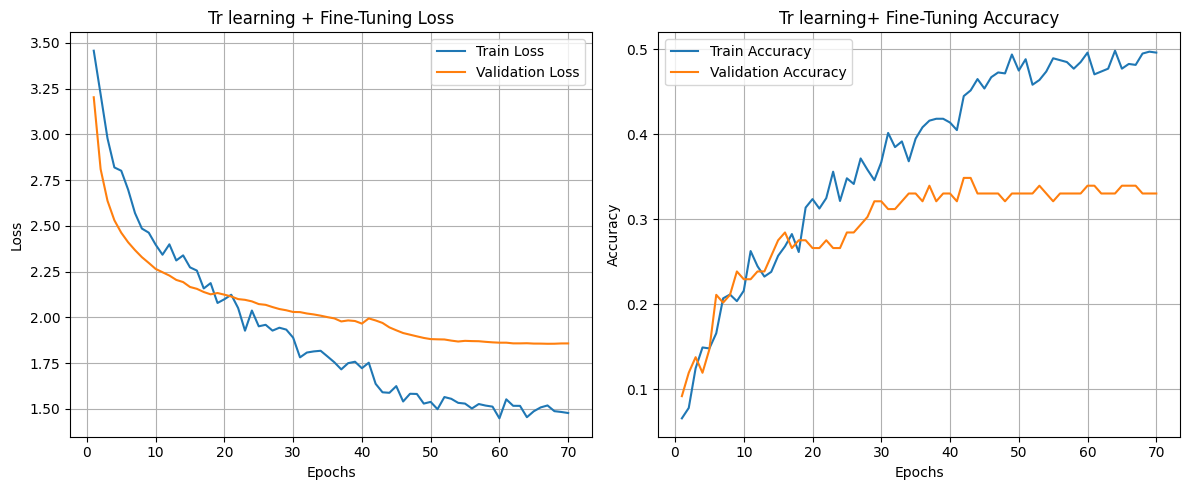

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step


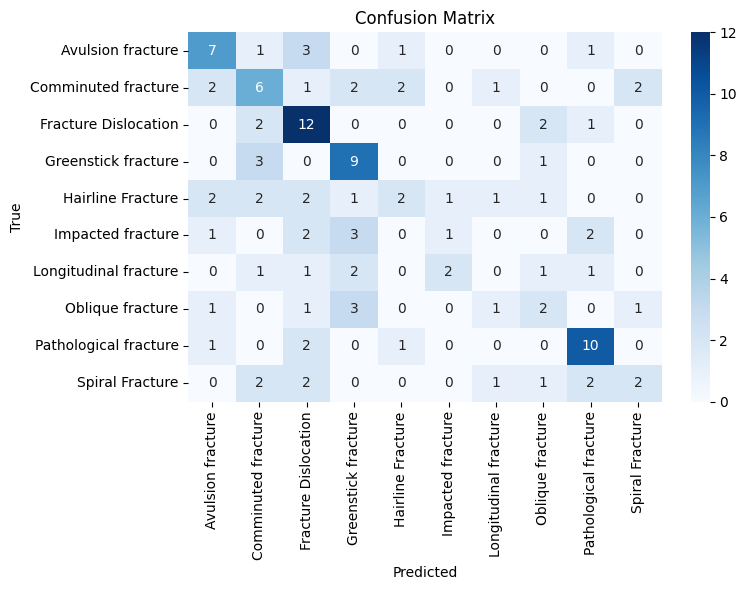


Test Accuracy : 0.4215

Classification Report:

                       precision    recall  f1-score   support

    Avulsion fracture       0.50      0.54      0.52        13
  Comminuted fracture       0.35      0.38      0.36        16
 Fracture Dislocation       0.46      0.71      0.56        17
  Greenstick fracture       0.45      0.69      0.55        13
    Hairline Fracture       0.33      0.17      0.22        12
    Impacted fracture       0.25      0.11      0.15         9
Longitudinal fracture       0.00      0.00      0.00         8
     Oblique fracture       0.25      0.22      0.24         9
Pathological fracture       0.59      0.71      0.65        14
      Spiral Fracture       0.40      0.20      0.27        10

             accuracy                           0.42       121
            macro avg       0.36      0.37      0.35       121
         weighted avg       0.38      0.42      0.39       121



In [ ]:
corriger ca import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)


loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

accuracy = history1.history["accuracy"] + history2.history["accuracy"]
val_accuracy = history1.history["val_accuracy"] + history2.history["val_accuracy"]

epochs = range(1, len(loss) + 1)


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Tr learning + Fine-Tuning Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tr learning + Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


y_pred_probs = model.predict(data_test1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Vraies classes
y_true = data_test1.classes

# Noms des classes
class_names = list(data_test1.class_indices.keys())


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy : {acc:.4f}")



print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
train_classes = set(data_train1.class_indices.keys())
test_classes = set(data_test1.class_indices.keys())

print("Classes manquantes :", test_classes - train_classes)

Classes manquantes : set()


In [ ]:
print("Nombre de classes dans class_names :", len(class_names))
print("Classes présentes dans y_true :", np.unique(y_true))
print("Nombre de classes présentes :", len(np.unique(y_true)))

Nombre de classes dans class_names : 11
Classes présentes dans y_true : [ 0  2  3  4  5  6  7  8  9 10]
Nombre de classes présentes : 10


# **Exemple d'image mal classifiée**
Le modèle a classé l’image comme **Fracture Dislocation** alors que la vraie classe est **Avulsion fracture**, ce qui indique qu’il n’a pas appris des caractéristiques suffisamment discriminantes entre ces deux classes.

Même visuellement, la différence entre ces deux types de fractures n’est pas toujours évidente, ce qui rend la tâche difficile non seulement pour le modèle mais aussi pour l’observateur humain.

Cela signifie que le modèle se base sur des indices visuels qui peuvent être ambigus ou insuffisants, notamment à cause :

* de la complexité des images radiographiques,
* du manque de données représentatives,
*ou de la faible distinction visuelle entre certaines classes

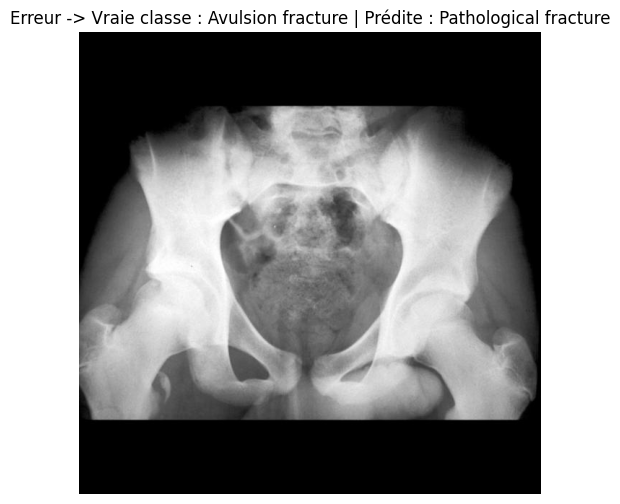

In [ ]:
# Affichage d'une image mal classée
bad = np.argwhere(y_true != y_pred)

if len(bad) > 0:
    index_bad = bad[0][0]

    # chemin de l'image
    chemin_image = data_test1.filepaths[index_bad]

    # lecture image
    img = plt.imread(chemin_image)

    # noms des classes
    noms_des_classes = list(data_test1.class_indices.keys())

    # vraie classe et prédiction
    nom_vraie_classe = noms_des_classes[y_true[index_bad]]
    nom_classe_predite = noms_des_classes[y_pred[index_bad]]

    # affichage
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Erreur -> Vraie classe : {nom_vraie_classe} | Prédite : {nom_classe_predite}")
    plt.axis('off')
    plt.show()

# **DATA augmentor**
Les résultats obtenus ne sont pas satisfaisants, avec une accuracy globale faible et plusieurs classes non correctement détectées. Cela montre que le modèle ne parvient pas à bien généraliser les différentes catégories de fractures.

Afin d’améliorer les performances, une étape de data augmentation manuelle a été réalisée. L’objectif est d’augmenter le nombre d’images par classe jusqu’à un seuil de 120 images afin de réduire le déséquilibre entre les classes et améliorer l’apprentissage.

La méthode d’augmentation utilisée repose sur des transformations simples appliquées aux images existantes :

rotation légère (±10°),
variation de la luminosité,
variation du contraste.

Ces transformations permettent de générer de nouvelles images réalistes à partir des données initiales sans modifier leur contenu médical.

Le code permet ainsi :

de copier les images originales,
puis de générer automatiquement des images augmentées pour atteindre le seuil fixé.

In [ ]:
import os
import shutil
import Augmentor

input_path = "/content/drive/MyDrive/base_sep/train"
output_path = "/content/drive/MyDrive/base_sep/train_augmm"

TARGET = 120

os.makedirs(output_path, exist_ok=True)

print("===== AUGMENTATION DU TRAIN UNIQUEMENT =====\n")

for cls in sorted(os.listdir(input_path)):

    input_class = os.path.join(input_path, cls)

    if not os.path.isdir(input_class):
        continue

    output_class = os.path.join(output_path, cls)
    os.makedirs(output_class, exist_ok=True)

    images = [
        f for f in os.listdir(input_class)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    current = len(images)

    print(f"{cls} : {current} images")


    for img in images:
        shutil.copy2(
            os.path.join(input_class, img),
            os.path.join(output_class, img)
        )

    if current >= TARGET:
        print("Déjà assez d'images\n")
        continue

    needed = TARGET - current

    print(f"Création de {needed} images...")

    p = Augmentor.Pipeline(
        source_directory=input_class,
        output_directory=output_class
    )

    p.rotate(probability=0.5, max_left_rotation=5, max_right_rotation=5)


    p.zoom_random(
        probability=0.3,
        percentage_area=0.9
    )


    p.random_brightness(
        probability=0.5,
        min_factor=0.85,
        max_factor=1.15
    )

    p.random_contrast(
        probability=0.5,
        min_factor=0.85,
        max_factor=1.15
    )



    p.sample(needed)

    print(f"Total final : {TARGET}\n")


print("Augmentation terminée.")

===== AUGMENTATION DU TRAIN UNIQUEMENT =====

Avulsion fracture : 98 images
Création de 22 images...
Initialised with 98 image(s) found.
Output directory set to /content/drive/MyDrive/base_sep/train_augmm/Avulsion fracture.

Processing <PIL.Image.Image image mode=RGB size=640x640 at 0x78EDC7F279B0>: 100%|██████████| 22/22 [00:00<00:00, 30.35 Samples/s]


Total final : 120

Comminuted fracture : 118 images
Création de 2 images...
Initialised with 118 image(s) found.
Output directory set to /content/drive/MyDrive/base_sep/train_augmm/Comminuted fracture.

Processing <PIL.Image.Image image mode=RGB size=275x640 at 0x78EDC3D46660>: 100%|██████████| 2/2 [00:00<00:00, 20.03 Samples/s]

Total final : 120

Fracture Dislocation : 124 images


...

Total final : 120

Pathological fracture : 107 images
Création de 13 images...
Initialised with 107 image(s) found.
Output directory set to /content/drive/MyDrive/base_sep/train_augmm/Pathological fracture.

Processing <PIL.Image.Image image mode=RGB size=640x640 at 0x78EDE73E6BA0>: 100%|██████████| 13/13 [00:00<00:00, 26.83 Samples/s]


Total final : 120

Spiral Fracture : 68 images
Création de 52 images...
Initialised with 68 image(s) found.
Output directory set to /content/drive/MyDrive/base_sep/train_augmm/Spiral Fracture.

Processing <PIL.Image.Image image mode=RGB size=640x640 at 0x78EDC7F27950>: 100%|██████████| 52/52 [00:01<00:00, 30.86 Samples/s]

Total final : 120

Augmentation terminée.


In [ ]:
train_path ="/content/drive/MyDrive/base_sep/train_augmm"

for cls in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, cls)

    if os.path.isdir(class_path):
        nb = len([f for f in os.listdir(class_path)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"{cls} : {nb} images")

Avulsion fracture : 120 images
Comminuted fracture : 120 images
Fracture Dislocation : 124 images
Greenstick fracture : 120 images
Hairline Fracture : 120 images
Impacted fracture : 120 images
Longitudinal fracture : 120 images
Oblique fracture : 120 images
Pathological fracture : 120 images
Spiral Fracture : 120 images


In [ ]:


data_1 = "/content/drive/MyDrive/base_sep/train_augmm"
data_2 = "/content/drive/MyDrive/base_sep/val"
data_3 = "/content/drive/MyDrive/base_sep/test"

from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


NORM = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
data_train2 = NORM.flow_from_directory(
    data_1,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)


data_val2 = NORM.flow_from_directory(
    data_2,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


data_test2 = NORM.flow_from_directory(
    data_3,
    target_size=(224,224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


print(data_train2.class_indices)
print(data_val2.class_indices)
print(data_test2.class_indices)

Found 1204 images belonging to 10 classes.
Found 109 images belonging to 10 classes.
Found 121 images belonging to 10 classes.
{'Avulsion fracture': 0, 'Comminuted fracture': 1, 'Fracture Dislocation': 2, 'Greenstick fracture': 3, 'Hairline Fracture': 4, 'Impacted fracture': 5, 'Longitudinal fracture': 6, 'Oblique fracture': 7, 'Pathological fracture': 8, 'Spiral Fracture': 9}
{'Avulsion fracture': 0, 'Comminuted fracture': 1, 'Fracture Dislocation': 2, 'Greenstick fracture': 3, 'Hairline Fracture': 4, 'Impacted fracture': 5, 'Longitudinal fracture': 6, 'Oblique fracture': 7, 'Pathological fracture': 8, 'Spiral Fracture': 9}
{'Avulsion fracture': 0, 'Comminuted fracture': 1, 'Fracture Dislocation': 2, 'Greenstick fracture': 3, 'Hairline Fracture': 4, 'Impacted fracture': 5, 'Longitudinal fracture': 6, 'Oblique fracture': 7, 'Pathological fracture': 8, 'Spiral Fracture': 9}


# **5 VGG16 avec fine tunning (et data Augmentor)**


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Etape 1 : on gèle tout
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),          # stabilise l'échelle des features
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(data_train2.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

history1 = model.fit(
    data_train2,
    validation_data=data_val2,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

# Etape 2 : fine-tuning — on débloque le bloc 5 uniquement
base_model.trainable = True

for layer in base_model.layers:
    if not layer.name.startswith("block5"):
        layer.trainable = False

# Recompiler avec un faible learning rate (obligatoire après changement de trainable)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()  # vérifier le nombre de paramètres entraînables

# Continuer l'entraînement
history2 = model.fit(
    data_train2,
    validation_data=data_val2,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

test_loss, test_acc = model.evaluate(data_test2)

print("\nTest accuracy :", test_acc)
print("Test loss :", test_loss)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,634 (56.65 MB)

 Trainable params: 134,922 (527.04 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,634 (56.65 MB)

 Trainable params: 7,214,346 (27.52 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 417ms/step - accuracy: 0.6354 - loss: 1.1164 - val_accuracy: 0.3578 - val_loss: 1.9966 - learning_rate: 1.0000e-05
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.7176 - loss: 0.9103 - val_accuracy: 0.3670 - val_loss: 1.9598 - learning_rate: 1.0000e-05
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step - accuracy: 0.7284 - loss: 0.8828 - val_accuracy: 0.3853 - val_loss: 1.9327 - learning_rate: 1.0000e-05
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 253ms/step - accuracy: 0.7542 - loss: 0.7929 - val_accuracy: 0.4128 - val_loss: 1.8880 - learning_rate: 1.0000e-05
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - accuracy: 0.8073 - loss: 0.6754 - val_accuracy: 0.3945 - val_loss: 1.8511 - learning_rate: 1.0000e-05
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accuracy: 0.8339 - loss: 0.6272 - val_accuracy: 0.4220 - val_loss: 1.8377 - learning_rate: 1.0000e-05
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accu

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Etape 1 : on gèle tout
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),          # stabilise l'échelle des features
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(data_train2.num_classes, activation="softmax")
])

# Label smoothing : utile car plusieurs classes de fractures sont visuellement proches
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

# Poids de classe : compense le déséquilibre entre classes (8 à 17 images vues en test)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(data_train2.classes),
    y=data_train2.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights :", class_weights)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

history1 = model.fit(
    data_train2,
    validation_data=data_val2,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

# Etape 2 : fine-tuning — on débloque block4 + block5
# (block5 seul = trop peu de paramètres pour adapter les features
# génériques ImageNet aux textures radiologiques)
base_model.trainable = True

for layer in base_model.layers:
    if not (layer.name.startswith("block4") or layer.name.startswith("block5")):
        layer.trainable = False

# Recompiler avec un faible learning rate (obligatoire après changement de trainable)
model.compile(
    optimizer=Adam(learning_rate=5e-6),  # abaissé vs avant, car plus de couches débloquées
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()  # vérifier le nombre de paramètres entraînables

# Continuer l'entraînement
history2 = model.fit(
    data_train2,
    validation_data=data_val2,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

test_loss, test_acc = model.evaluate(data_test2)

print("\nTest accuracy :", test_acc)
print("Test loss :", test_loss)

## **Analyse des résultats & Métriques d'évaluation -VGG16-**
Les résultats obtenus montrent une amélioration significative des performances, avec une accuracy globale(test) de 0.74 (**74%**), ce qui indique que le modèle parvient globalement à bien classifier les différentes fractures.

On observe que la majorité des classes présentent des scores équilibrés en précision et en recall, ce qui reflète une bonne capacité de généralisation. Certaines classes se distinguent particulièrement :

* Pathological fracture et Longitudinal fracture montrent des performances élevées et stables (jusqu’à **0.85**),
* Greenstick fracture présente une très bonne précision (**0.93**), ce qui signifie peu de fausses prédictions.

Cependant, quelques variations existent :

* Spiral Fracture a un recall élevé (**0.90**) mais une précision plus faible (**0.60**), ce qui indique que le modèle la détecte bien mais avec plusieurs erreurs (confusions avec d’autres classes),
Avulsion et Comminuted fracture ont un recall plus faible (**0.60**), ce qui signifie que certaines images ne sont pas correctement reconnues.

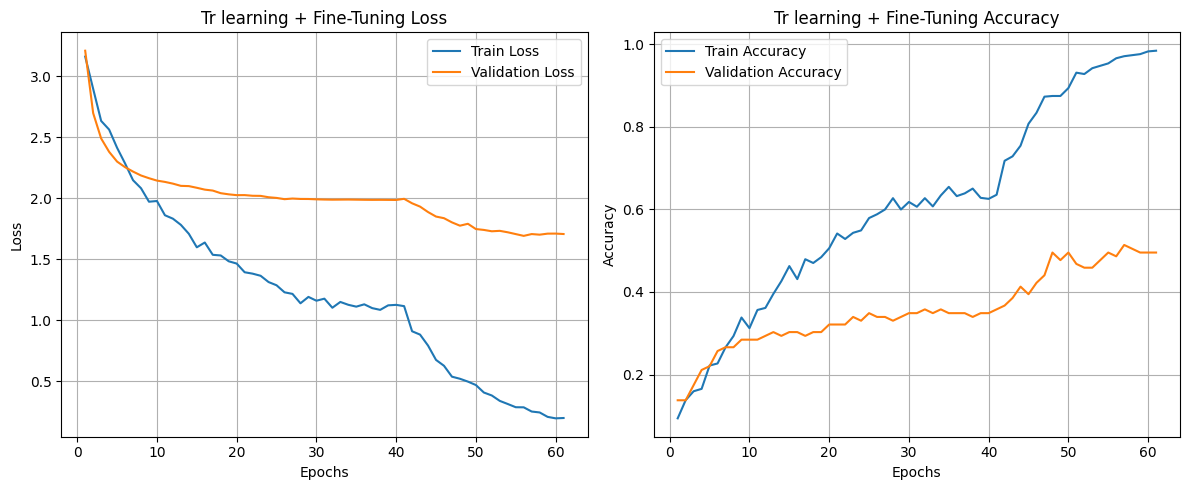

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step


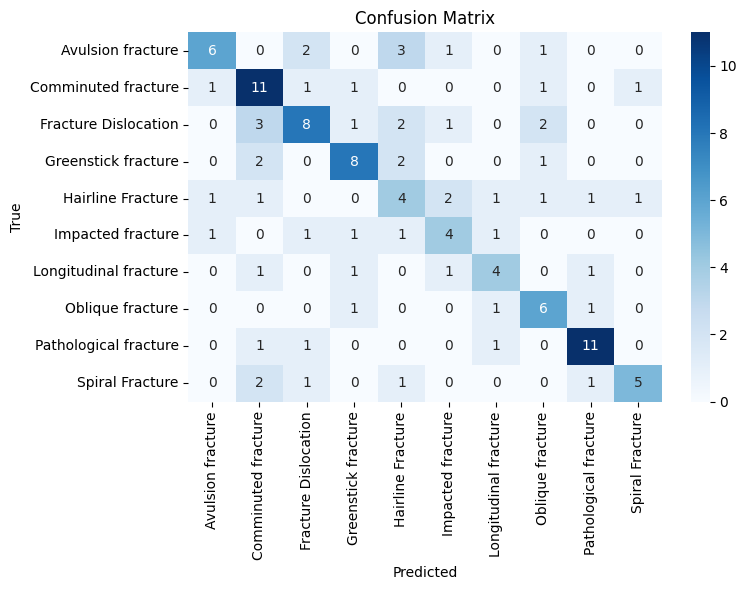


Test Accuracy : 0.5537

Classification Report:

                       precision    recall  f1-score   support

    Avulsion fracture       0.67      0.46      0.55        13
  Comminuted fracture       0.52      0.69      0.59        16
 Fracture Dislocation       0.57      0.47      0.52        17
  Greenstick fracture       0.62      0.62      0.62        13
    Hairline Fracture       0.31      0.33      0.32        12
    Impacted fracture       0.44      0.44      0.44         9
Longitudinal fracture       0.50      0.50      0.50         8
     Oblique fracture       0.50      0.67      0.57         9
Pathological fracture       0.73      0.79      0.76        14
      Spiral Fracture       0.71      0.50      0.59        10

             accuracy                           0.55       121
            macro avg       0.56      0.55      0.55       121
         weighted avg       0.56      0.55      0.55       121



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)


loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

accuracy = history1.history["accuracy"] + history2.history["accuracy"]
val_accuracy = history1.history["val_accuracy"] + history2.history["val_accuracy"]

epochs = range(1, len(loss) + 1)


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Tr learning + Fine-Tuning Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Tr learning + Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


y_pred_probs = model.predict(data_test1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Vraies classes
y_true = data_test2.classes

# Noms des classes
class_names = list(data_test2.class_indices.keys())


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy : {acc:.4f}")



print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
labels = data_test2.classes
class_names = list(data_test2.class_indices.keys())

# Compter les images par classe
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"{class_names[i]} : {count} images")

Avulsion fracture : 20 images
Comminuted fracture : 20 images
Fracture Dislocation : 20 images
Greenstick fracture : 20 images
Hairline Fracture : 20 images
Impacted fracture : 20 images
Longitudinal fracture : 20 images
Oblique fracture : 20 images
Pathological fracture : 20 images
Spiral Fracture : 20 images


# **Conclusion**
Les résultats obtenus mettent en évidence des différences très marquées selon les stratégies d’apprentissage utilisées.

Le CNN de base présente des performances très faibles, avec une accuracy d’environ **13 à 14 %**, ce qui montre clairement ses limites face à la complexité des images médicales et au manque de données.

L’introduction du transfer learning avec VGG16 (sans fine-tuning) améliore nettement les résultats, qui atteignent environ **41 %**. Cela confirme que l’utilisation de caractéristiques déjà apprises sur de grands datasets permet une meilleure extraction d’information par rapport à un modèle entraîné de zéro.

En revanche, le fine-tuning appliqué seul ne donne pas de bons résultats, avec une chute des performances autour de (**13 %**) . Cela peut s’expliquer par la sensibilité du modèle aux petits datasets, où le dégel partiel des couches entraîne une instabilité de l’apprentissage.

Enfin, la meilleure configuration est obtenue en combinant fine-tuning et data augmentation, avec une accuracy qui atteint environ **74 %**. Cette amélioration montre clairement que l’enrichissement des données joue un rôle déterminant dans la capacité du modèle à généraliser correctement


# **6.1 Visualisation des filtres**
La figure montre le 2ème filtre  de la première couche de VGG16, séparé en trois canaux (rouge, vert, bleu). Chaque image représente les poids du filtre pour un canal, affichés en niveaux de gris.

On observe un centre plus clair entouré de zones plus sombres, ce qui indique que ce filtre détecte des variations d’intensité ou des motifs locaux. Lors de l’application sur une image, il activera fortement les régions présentant ce type de caractéristiques.


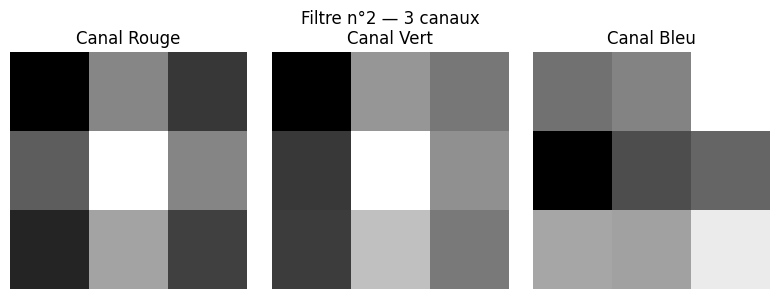

In [ ]:
base_model = model4.layers[0]

filters, biases, *_ = base_model.layers[1].get_weights()

# Normalisation sur [0, 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Visualisation des 3 canaux du filtre n°2
f = filters[:, :, :, 1]

plt.figure(figsize=(8, 3))
for i, canal in enumerate(['Rouge', 'Vert', 'Bleu']):
    plt.subplot(1, 3, i + 1)
    plt.imshow(f[:, :, i], cmap='gray')
    plt.title(f'Canal {canal}')
    plt.axis('off')
plt.suptitle('Filtre n°2 — 3 canaux')
plt.tight_layout()
plt.show()

# **6.2 Carte d'activation (Feature Map)**

On applique le premier filtre de VGG16 sur une image de test pour visualiser ce que le modèle voit, c'est-à-dire les zones de l'image qui activent le plus ce filtre.



In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input

#  Charger une image de test
img_path = data_test2.filepaths[1]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Préprocessing VGG16
img_array = preprocess_input(img_array)

# Modèle intermédiaire basé sur VGG16 (IMPORTANT)
feature_map_model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[1].output
)

# Feature maps
feature_maps = feature_map_model.predict(img_array)

# Affichage
plt.figure(figsize=(6, 6))
plt.imshow(feature_maps[0, :, :, 0], cmap='viridis')
plt.title("Feature Map - VGG16 (Filtre 1)")
plt.axis('off')
plt.show()

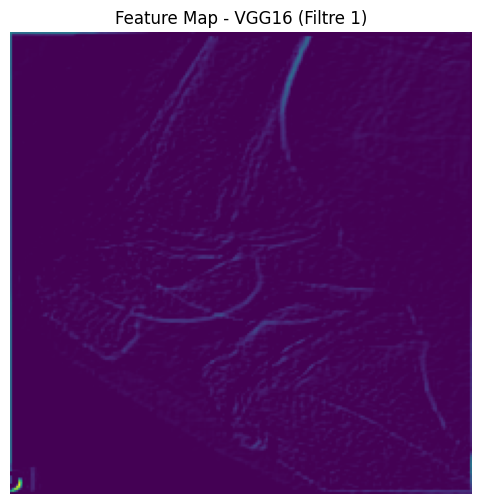


La feature map obtenue représente la réponse d’un filtre de la première couche du modèle VGG16 appliqué à une image de fracture.

On observe que le filtre ne conserve pas l’image complète, mais met en évidence uniquement certaines zones importantes. Les contours, les bords et les variations d’intensité sont principalement détectés, tandis que les détails non pertinents sont atténués.

Ce qui montre que les premières couches du réseau ne cherchent pas encore à reconnaître une fracture, mais plutôt à extraire des caractéristiques simples comme les formes, les contrastes et les contours.

# **7.1 Sauvegard du modèle**

In [ ]:
model.save('/content/drive/MyDrive/arch_clas_os.h5')
# Sauvegarde du modèle (architecture)
model_json = model.to_json()

with open('/content/drive/MyDrive/arch_clas_os.json', 'w') as json_file:
    json_file.write(model_json)

# Sauvegarde des poids
model.save_weights('/content/drive/MyDrive/arch_class_os.weights.h5')


# **7.2 Creation d'application web avec Streamlit**
Ce code permet de créer une application web avec Streamlit pour la classification des fractures osseuses à partir d’images médicales.

Dans un premier temps, les bibliothèques nécessaires sont importées pour :

l’interface web (Streamlit),
le traitement d’image (OpenCV, PIL, NumPy),
et le chargement du modèle Keras.

Le modèle de deep learning est chargé à partir de deux fichiers :

un fichier JSON contenant l’architecture du réseau,
un fichier .h5 contenant les poids entraînés.

Une liste nom_classe est définie afin de représenter les 10 types de fractures à prédire.

Lorsqu’un utilisateur importe une image, celle-ci est :

convertie en tableau numérique,
redimensionnée à 224×224 pixels,
normalisée (valeurs entre 0 et 1),
puis adaptée au format attendu par le modèle.

Le modèle effectue ensuite une prédiction et retourne :

la classe de fracture prédite,
la probabilité associée.

Enfin, l’application affiche sur l’interface :

l’image chargée,
le type de fracture détecté,
et la confiance de la prédiction.

**Le code a été légèrement adapté afin d’être compatible avec TensorFlow 1.9, ce qui permet de garantir le bon chargement du modèle et son exécution correcte dans l’application Streamlit pour la classification des fractures**.

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Mar 28 08:48:18 2023

@author: Samira
"""

import streamlit as st
import cv2
from PIL import Image
import numpy as np
from tensorflow.keras.models import model_from_json
from tensorflow.keras.models import load_model as keras_load_model

nom_classe = [
    "Avulsion fracture",
    "Comminuted fracture",
    "Fracture Dislocation",
    "Greenstick fracture",
    "Hairline Fracture",
    "Impacted fracture",
    "Longitudinal fracture",
    "Oblique fracture",
    "Pathological fracture",
    "Spiral Fracture"
]

@st.cache_data
def load_model():
    model_architecture = 'arch_clas_os.json'
    model_weights = 'arch_clas_os.h5'
    model = 	model_from_json(open(model_architecture).read())
    model.load_weights(model_weights)
    return model

with st.spinner('Model is being loaded..'):
  model=load_model()


st.write("""
#  Classification des fractures osseuses
""")

file = st.file_uploader("Upload the image to be classified", type=["jpg", "png", "jpeg"])


def upload_predict(image, model):
    image = np.asarray(image)
    image = image.astype('float32')
    image = cv2.resize(image, (224, 224))
    image /= 255
    image = image.reshape([-1, 224, 224, 3])

    prediction = model.predict(image)
    pred_class = np.argmax(prediction, axis=1)

    return pred_class, prediction

if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, width="stretch")

    pred_class, prediction = upload_predict(image, model)

    st.write(" Type de fracture :", nom_classe[pred_class[0]])
    st.write(" Probabilité :", float(prediction[0][pred_class[0]]))

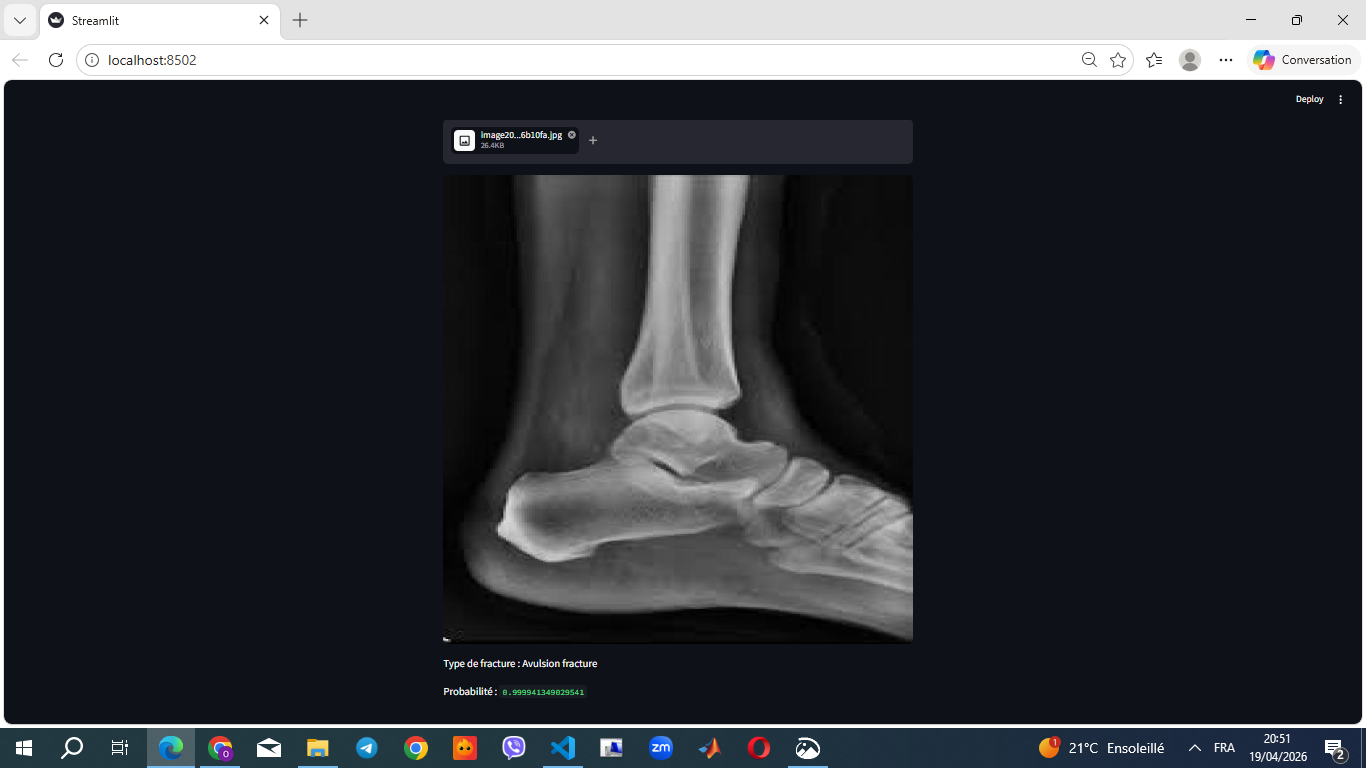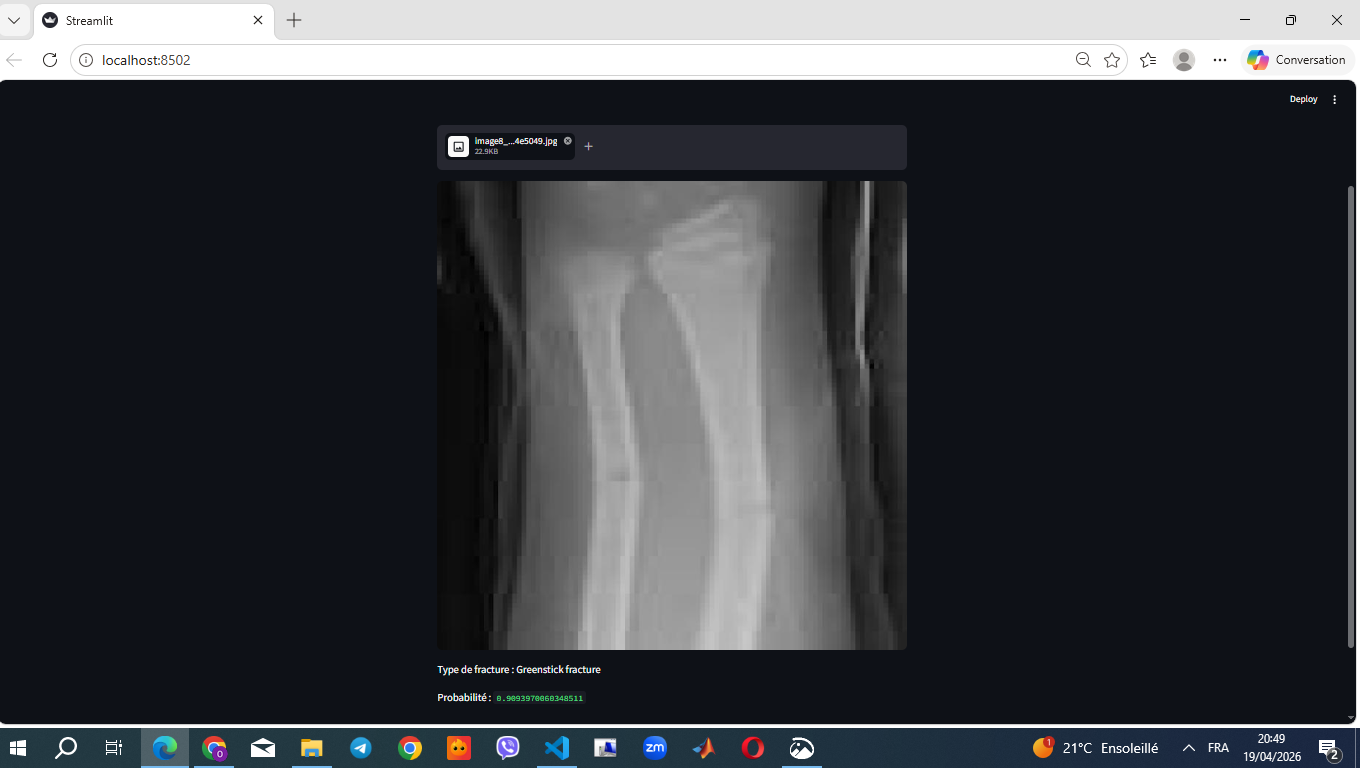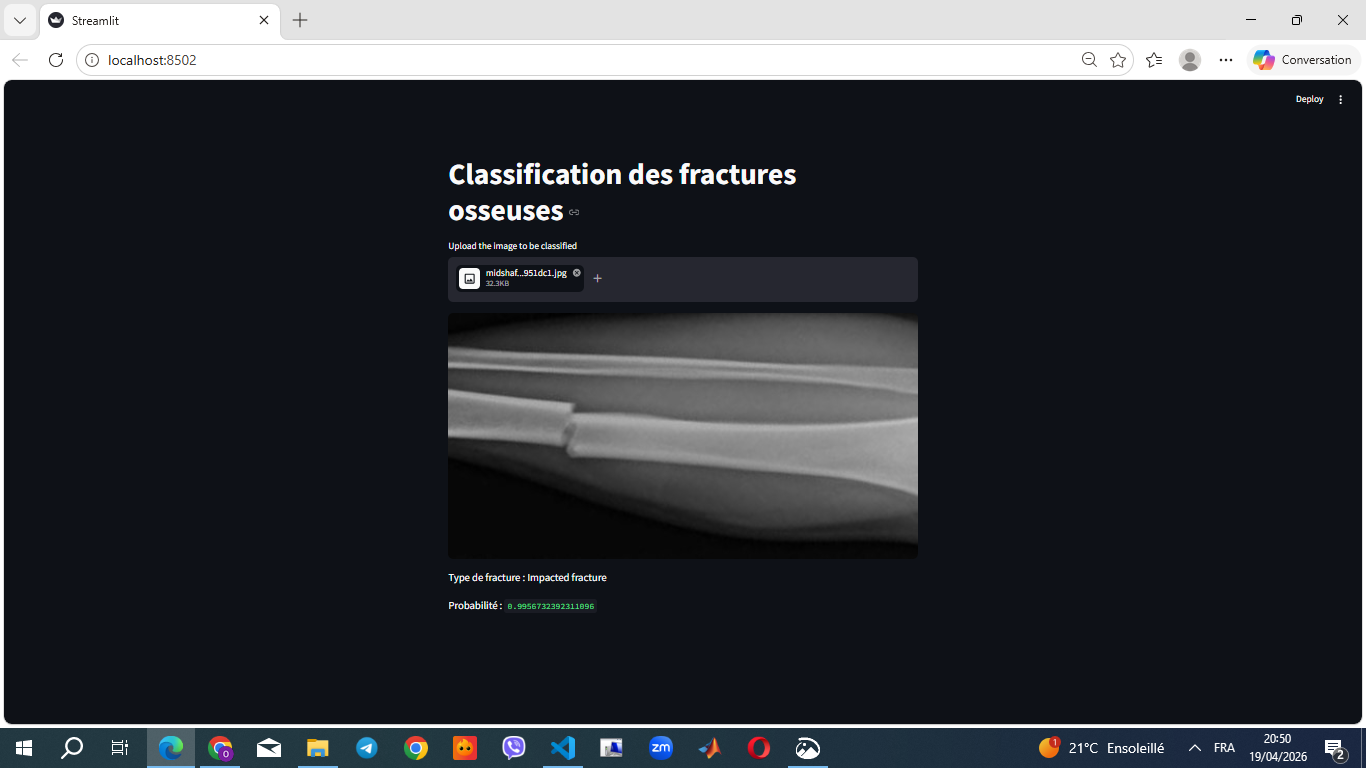